In [2]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.pyplot import cm
import re
import math
import matplotlib.gridspec as gridspec
import json
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd

api = wandb.Api(timeout=19)

In [3]:
# Fetch runs for a specific project
def fetch_runs(api, entity, project_name, filters, order=None):
    if order:
        runs = api.runs(f"{entity}/{project_name}", filters=filters, order=order)
    else:
        runs = api.runs(f"{entity}/{project_name}", filters=filters)
    #print(f"Runs for project '{project_name}':")
    return runs

In [4]:
def same_config(config1, config2, keys=['normtype']):
    for key in keys:
        if config1[key] != config2[key]:
            return False
    return True

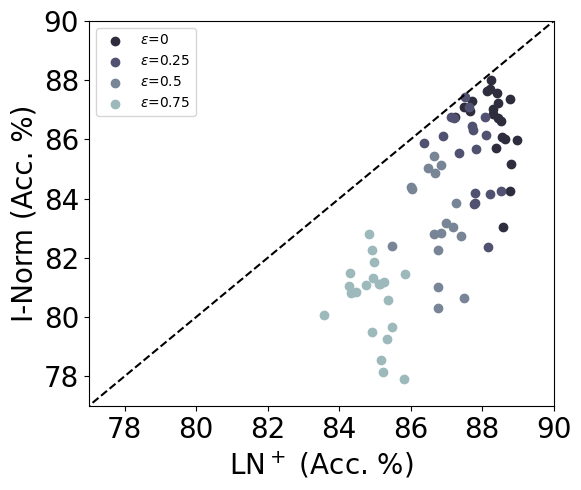

In [5]:
fig, ax = plt.subplots(figsize=(6,5))

# Example brightness factors used
brightness_values = [0, 0.25, 0.5, 0.75]

# Normalize brightness for colormap mapping
norm = mcolors.Normalize(vmin=min(brightness_values), vmax=max(brightness_values))

def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Create a grayscale colormap from 20% (dark gray) to 100% (black)
cmap = truncate_colormap(plt.get_cmap('bone'), 0.2, 0.7)

scatter_handles = []  # For legend proxy if needed

list_line = range(100)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.plot(list_line, list_line, color='black', linestyle='--')
ax.set_ylabel(f"I-Norm (Acc. %)", fontsize=20)
ax.set_xlabel("LN$^+$ (Acc. %)", fontsize=20)

for bfi in brightness_values:
    color = cmap(norm(bfi))

    runs_dict = dict()

    runs_dict["runs_vanilla_dann_layernorm"] = fetch_runs(api, entity='project_danns', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 0, "config.normtype": 0, "config.normtype_detach": 0,
                                                            "config.excitation_training": 1, "config.layer_norm": 1, "config.use_testset": True}, order="-summary_metrics.test_acc")
    runs_dict["runs_homeostasis"] = fetch_runs(api, entity='project_danns', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 1, "config.normtype": 0, "config.normtype_detach": 1, "config.lambda_homeo": 0.01,
                                                            "config.excitation_training": 1, "config.layer_norm": None, "config.feedback_alignment":0, "config.use_testset": True, "config.ln_feedback":'full'}, order="-summary_metrics.test_acc")

    top_n = len(runs_dict["runs_vanilla_dann_layernorm"])

    for top in range(top_n):
        vanilla_dann_acc = runs_dict["runs_vanilla_dann_layernorm"][top].summary['test_acc']
        for rn in runs_dict["runs_homeostasis"]:
            if same_config(rn.config, runs_dict["runs_vanilla_dann_layernorm"][top].config, keys=['lr', 'wd','inhib_lrs', 'momentum', 'inhib_momentum']):
                sc = ax.scatter( vanilla_dann_acc, rn.summary['test_acc'], color=color, label=f"$\epsilon$={bfi}" if top == 0 else None)
                break  # Only label once per brightness group
ax.set_xlim(77, 90)
ax.set_ylim(77, 90)
ax.legend()

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

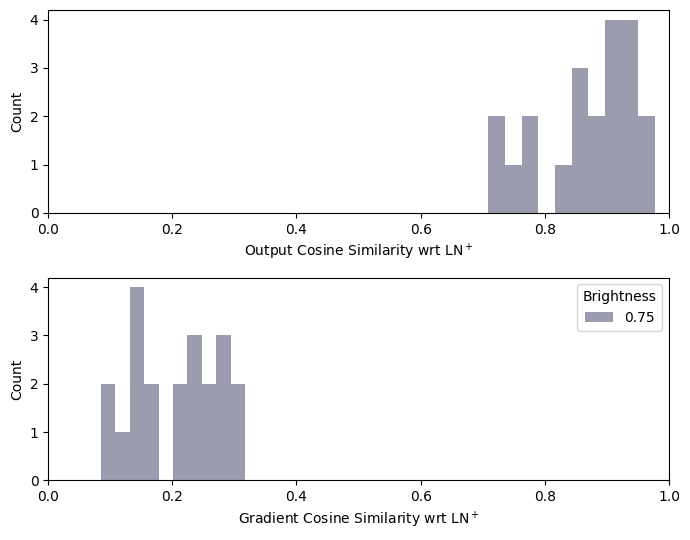

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors

# -------------------------
# Helpers
# -------------------------

def truncate_colormap(cmap, minval=0.0, maxval=0.85, n=100):
    return colors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )

def safe_float(x):
    """Convert x to float if possible, otherwise return None."""
    try:
        v = float(x)
        if np.isnan(v):
            return None
        return v
    except Exception:
        return None

brightness_factors = [0.75] #, 0.25, 0.5, 0.75]
layers_to_average = ["fc0", "fc1"]

trunc_bone = truncate_colormap(cm.get_cmap("bone"), 0.4, 0.9)
norm = colors.Normalize(vmin=min(brightness_factors), vmax=max(brightness_factors))


# -------------------------
# Data collection
# -------------------------

def collect_last_epoch_summary(alignment_prefix):
    """Collect last-epoch summary values and average across layers."""
    brightness_to_values = {}

    for bright in brightness_factors:
        run_values = []

        runs = fetch_runs(
            api,
            entity="project_danns",
            project_name="Luminosity_LNHomeostasis",
            filters={
                "config.dataset": "fashionmnist",
                "config.brightness_factor": bright,
                "config.homeostasis": 1,
                "config.normtype": 0,
                "config.normtype_detach": 1,
                "config.excitation_training": 1,
                "config.layer_norm": None,
                "config.use_testset": True,
                "config.ln_feedback": 'full',
                "config.lambda_homeo": 0.01,
            },
            order="-summary_metrics.test_acc"
        )

        for run in runs:
            layer_vals = []

            for layer in layers_to_average:
                key = f"{alignment_prefix}{layer}"

                if key not in run.summary:
                    continue

                val = safe_float(run.summary[key])
                if val is not None:
                    layer_vals.append(val)

            if len(layer_vals) > 0:
                run_values.append(np.mean(layer_vals))

        if len(run_values) > 0:
            brightness_to_values[bright] = np.array(run_values)

    return brightness_to_values


# Collect both datasets
output_data = collect_last_epoch_summary("output_alignment_")
grad_data   = collect_last_epoch_summary("gradient_alignment_")


# -------------------------
# Plotting (subplots)
# -------------------------

fig, axes = plt.subplots(2, 1, figsize=(7, 5.5), sharex=False)

# --- Top: Output alignment ---
ax = axes[0]
for bright, values in output_data.items():
    ax.hist(values, bins=10, alpha=0.6,
            color=trunc_bone(norm(bright)), label=str(bright))

ax.set_xlabel("Output Cosine Similarity wrt LN$^+$")
ax.set_ylabel("Count")
ax.set_xlim(0, 1)
# ax.set_yscale('log')

# --- Bottom: Gradient alignment ---
ax = axes[1]
for bright, values in grad_data.items():
    ax.hist(values, bins=10, alpha=0.6,
            color=trunc_bone(norm(bright)),
            # rwidth=0.9,
            label=str(bright))

ax.set_xlabel("Gradient Cosine Similarity wrt LN$^+$")
ax.set_ylabel("Count")
ax.legend(title="Brightness")
ax.set_xlim(0, 1)
# ax.set_yscale('log')

plt.tight_layout()
plt.tight_layout()
plt.show()
